# Cluster Speed Comparisons

This notebook will demo different clustering algorithms and compare the speed between them. The following are:
- Butina
- KMeans
- BitBirch

For the Butina and KMeans clustering, both the RDKit and Scikit-Learn models would be used as well as the MLX version.

In [1]:
import time
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import bblean
from rdkit.ML.Cluster import Butina
from rdkit import DataStructs, Chem
from sklearn.cluster import KMeans
from rdkit.Chem import rdFingerprintGenerator
from sklearn.metrics import pairwise_distances_argmin_min
from mlx_cluster import fp_to_mlx
from mlx_cluster import butina as mlx_butina
from mlx_cluster import KMeans as mlx_KMeans

## Helper Functions
Three helper functions are created.

In [2]:
def total_time(total_time):
    total = float(round(total_time, 2))
    print(f"Total Time: {total} Sec")
    return total

def tanimoto_matrix(fp_list):
    """
    Calculate tanimoto distance matrix.
    """
    matrix = []
    for i in range(1, len(fp_list)):
        # Compare the current fingerprint against all the previous ones in the list
        similarities = DataStructs.BulkTanimotoSimilarity(fp_list[i], fp_list[:i])
        # Since we need a distance matrix, calculate 1-x for every element in similarity matrix
        matrix.extend([1 - x for x in similarities])
    return matrix

def butina_cluster(fingerprints, cutoff=0.2):
    """
    Calculate butina clusters
    """
    # matrix
    distance_matrix = tanimoto_matrix(fingerprints)
    # cluster
    clusters = Butina.ClusterData(distance_matrix, len(fingerprints), cutoff, isDistData=True)
    clusters = sorted(clusters, key=len, reverse=True)
    return clusters

# Prepare the Dataset

The dataset was downloaded from the [BitBIRCH repository](https://github.com/mqcomplab/bblean/tree/main). These molecules are natural products. The file contains more than 64K molecules. For speed, only the first 10K molecules will be selected for clustering.



In [3]:
# load molecules
smiles = bblean.load_smiles("dataset/chembl-33-natural-products-subset.smi")

# take first 10_000 molecules
smi_list = smiles[:10_000]

# convert smi into RDKit object
mol_list = [Chem.MolFromSmiles(smi) for smi in smi_list]

print(f"The number of molecules for clustering: {len(mol_list)}")

The number of molecules for clustering: 10000


## Preparing DataFrame
In this notebook, a table will be created containing the smiles string. For each cluster type, the cluster and the centroid will be appended. This will be a good way to visualize/inspect the clustering outcomes in tabular format.

In [4]:
df = pd.DataFrame(smi_list, columns=["smiles"])
df.head()

,smiles
0,BrC1CCC(Br)C(Br)CCC(Br)C(Br)CCC1Br\n
1,BrCCCCCCBr\n
2,BrCc1cc(Br)c2cc(NBr)c(Br)c(Br)c2c1\n
3,BrCc1cc(Br)c2cc(NBr)c(Br)cc2c1Br\n
4,BrCc1cc2cc(Br)c(NBr)cc2c(Br)c1Br\n


## Prepare the Fingerpritns
The dataset will be further prepared. This is one of the bottlenecks to using GPU. As of now, the calculation of molecular fingerprints is done on the CPU.

To keep things consistent, the RDKit fingeprritns will be used, as seen in the bitbirch tutorial.

In [5]:
# set rdkit fingerprint generator
fp_gen = rdFingerprintGenerator.GetRDKitFPGenerator(fpSize=2048)
# calculate rdkit fingerprint
rdkit_fps = fp_gen.GetFingerprints(mol_list, numThreads=10)

# Clustering
Three different clustering methods will be demoed below. First the Butina and KMeans clustering will be done using RDKit and Scikit-Learn, respectively

## Butina Clustering

In [6]:
# record time
start = time.time()

# butina clustering
clusters = butina_cluster(rdkit_fps)

# end time
end = time.time()
butina_time = total_time(end-start)

Total Time: 13.73 Sec


## Label Butina Clusters

The clusters and centroid can be extracted for each Butina cluster. The information can be appended to the DataFrame. For interactivity, teh table can be sorted based on cluster number or cluster centroid.

In [7]:
# extract cluster group and centroid
bclusters = {conf: x for x, cluster in enumerate(clusters) for conf in cluster}
bcentroid = {conf: (conf == cluster[0]) for cluster in clusters for conf in cluster}

# append info to dataframe
df['butina_clusters'] = bclusters
df['butina_centroid'] = bcentroid
df.head()

,smiles,butina_clusters,butina_centroid
0,BrC1CCC(Br)C(Br)CCC(Br)C(Br)CCC1Br\n,3354,True
1,BrCCCCCCBr\n,3353,True
2,BrCc1cc(Br)c2cc(NBr)c(Br)c(Br)c2c1\n,859,False
3,BrCc1cc(Br)c2cc(NBr)c(Br)cc2c1Br\n,859,False
4,BrCc1cc2cc(Br)c(NBr)cc2c(Br)c1Br\n,859,True


## KMeans Clustering
KMeans offers an advantage over other clusterings as users can specifiy the number of clusters to generate.

In [8]:
# convert fp into np.array
array = np.array(rdkit_fps)

# record time
start = time.time()

# define and fit the model
kmeans = KMeans(n_clusters=200, random_state=0).fit(array)

# end time
end = time.time()
kmeans_time = total_time(end-start)

Total Time: 2.23 Sec


## Label KMeans Clusters

The clusters and centroid can be extracted for each Kmeans cluster. The information is attributes can be extracted and appended to the table like the Butina clustering above.

In [9]:
# extract clusters
kcluster = kmeans.labels_
kcentroid, _ = pairwise_distances_argmin_min(kmeans.cluster_centers_, rdkit_fps)

# append info to dataframe
df['KMeans'] = kcluster
df['KMeans_centroid'] = False
df.loc[kcentroid, 'KMeans_centroid'] = True
df.head()

,smiles,butina_clusters,butina_centroid,KMeans,KMeans_centroid
0,BrC1CCC(Br)C(Br)CCC(Br)C(Br)CCC1Br\n,3354,True,183,False
1,BrCCCCCCBr\n,3353,True,183,False
2,BrCc1cc(Br)c2cc(NBr)c(Br)c(Br)c2c1\n,859,False,27,False
3,BrCc1cc(Br)c2cc(NBr)c(Br)cc2c1Br\n,859,False,27,False
4,BrCc1cc2cc(Br)c(NBr)cc2c(Br)c1Br\n,859,True,27,False


# MLX clustering
Here the Butina and KMeans clustering will be done on MLX. This raises another bottleneck - converting the fingerprints from np.array to mlx.array. A simple helper function has been made to handle this, though users may also use the mx.array() directly for conversion.

In [10]:
mlx_fp = fp_to_mlx(rdkit_fps)

### MLX Butina Clustering

In [11]:
# record time
start = time.time()

butina_mlx = mlx_butina(mlx_fp)

# end time
end = time.time()
mlx_butina_time = total_time(end - start)

Total Time: 1.98 Sec


Append MLX Butina clustering information.

In [12]:
# extract cluster group and centroid
bclusters = {conf: x for x, cluster in enumerate(butina_mlx) for conf in cluster}
bcentroid = {conf: (conf == cluster[0]) for cluster in butina_mlx for conf in cluster}

# append info to dataframe
df['mlx_butina_clusters'] = bclusters
df['mlx_butina_centroid'] = bcentroid
df.head()

,smiles,butina_clusters,butina_centroid,KMeans,KMeans_centroid,mlx_butina_clusters,mlx_butina_centroid
0,BrC1CCC(Br)C(Br)CCC(Br)C(Br)CCC1Br\n,3354,True,183,False,3354,True
1,BrCCCCCCBr\n,3353,True,183,False,3353,True
2,BrCc1cc(Br)c2cc(NBr)c(Br)c(Br)c2c1\n,859,False,27,False,859,False
3,BrCc1cc(Br)c2cc(NBr)c(Br)cc2c1Br\n,859,False,27,False,859,False
4,BrCc1cc2cc(Br)c(NBr)cc2c(Br)c1Br\n,859,True,27,False,859,True


## MLX KMeans

In [13]:
# record time
start = time.time()

# define and fit the model
kmeans = mlx_KMeans(n_clusters=200, random_state=0).fit(mlx_fp)

# end time
end = time.time()
mlx_kmeans_time = total_time(end-start)

Total Time: 0.58 Sec


Append MLX KMeans clustering information.

In [14]:
# extract clusters
kcluster = np.array(kmeans.labels_)
kcentroid, _ = np.array(kmeans.pairwise_distances_argmin_min(mlx_fp))

# append info to dataframe
df['mlx_KMeans'] = np.array(kcluster)
df['mlx_KMeans_centroid'] = False
df.loc[np.array(kcentroid), 'mlx_KMeans_centroid'] = True
df.head()

,smiles,butina_clusters,butina_centroid,KMeans,KMeans_centroid,mlx_butina_clusters,mlx_butina_centroid,mlx_KMeans,mlx_KMeans_centroid
0,BrC1CCC(Br)C(Br)CCC(Br)C(Br)CCC1Br\n,3354,True,183,False,3354,True,90,False
1,BrCCCCCCBr\n,3353,True,183,False,3353,True,90,False
2,BrCc1cc(Br)c2cc(NBr)c(Br)c(Br)c2c1\n,859,False,27,False,859,False,38,False
3,BrCc1cc(Br)c2cc(NBr)c(Br)cc2c1Br\n,859,False,27,False,859,False,38,False
4,BrCc1cc2cc(Br)c(NBr)cc2c(Br)c1Br\n,859,True,27,False,859,True,38,True


## BitBIRCH

BitBIRCH is the newest clustering algorithm. It was crated to handle larger libraries. This is advantages as commercial libraries increase in size. In the reported manuscript, BitBIRCH was able to cluster 1,500,000 molecules in 5 hours - more than 1000x faster than Butina.

BitBIRCH comes with their own molecular fingerprint. While the fingerprint generated above can be used, the BitBIRCH comes with options to "pack" the fingerprints. This will essentially reduce the sparse integers in the data, compacting the fingerprint from 2048 bits sinto 256 bits.

In [15]:
# calculate fingerprint
fps_bb = bblean.fps_from_smiles(smi_list, pack=True, n_features=2048, kind="rdkit")

# record time
start = time.time()

# bitbirch clustering
tree = bblean.BitBirch()
tree.fit(fps_bb)

# end time
end = time.time()
bitbirch_time = total_time(end - start)

Total Time: 0.3 Sec


## Label BitBIRCH Clusters

Again, the clusters and centroids are extracted for each BitBIRCH cluster and appended to the DataFrame.

In [16]:
# extract cluster
bbcluster = {}
for cluster_id, mol_indices in enumerate(clusters):
    for x in mol_indices:
        bbcluster[x] = cluster_id
bbcentroid = [c[0] for c in clusters]

# append info to DataFrame
df['BitBIRCH_Cluster'] = bbcluster
df['BitBIRCH_centroid'] = False
df.loc[bbcentroid, 'BitBIRCH_centroid'] = True
df

,smiles,butina_clusters,butina_centroid,KMeans,KMeans_centroid,mlx_butina_clusters,mlx_butina_centroid,mlx_KMeans,mlx_KMeans_centroid,BitBIRCH_Cluster,BitBIRCH_centroid
0,BrC1CCC(Br)C(Br)CCC(Br)C(Br)CCC1Br\n,3354,True,183,False,3354,True,90,False,3354,True
1,BrCCCCCCBr\n,3353,True,183,False,3353,True,90,False,3353,True
2,BrCc1cc(Br)c2cc(NBr)c(Br)c(Br)c2c1\n,859,False,27,False,859,False,38,False,859,False
3,BrCc1cc(Br)c2cc(NBr)c(Br)cc2c1Br\n,859,False,27,False,859,False,38,False,859,False
4,BrCc1cc2cc(Br)c(NBr)cc2c(Br)c1Br\n,859,True,27,False,859,True,38,True,859,True
...,...,...,...,...,...,...,...,...,...,...,...
9995,CC(=O)O[C@H]1[C@@H]2OC(=O)[C@@H]3c4ccoc4C[C@@H...,301,False,21,False,301,False,188,False,301,False
9996,CC(=O)O[C@H]1[C@@H]2O[C@@]3(C(C)(C)O)CC[C@](C)...,13,False,199,False,13,False,127,True,13,False
9997,CC(=O)O[C@H]1[C@@H]2O[C@H]2[C@H]2C[C@@]3(O)OC[...,1669,True,43,False,1669,True,127,False,1669,True
9998,CC(=O)O[C@H]1[C@@H]2O[C@]2([C@H](C)[C@H]2CC(C)...,1581,True,33,False,1581,True,103,False,1581,True


# Performance Comparison

A simple bar chart shows the performance of the clustering on 10,000 molecules. BitBIRCH is able to do this under 0.5 seconds on my machine (MacBook Pro M2 Pro). This is followed by Butina and then KMeans.

Feel free to experiment with the size of the compound library and different molecular fingerprint types to see how this may affect speeds.

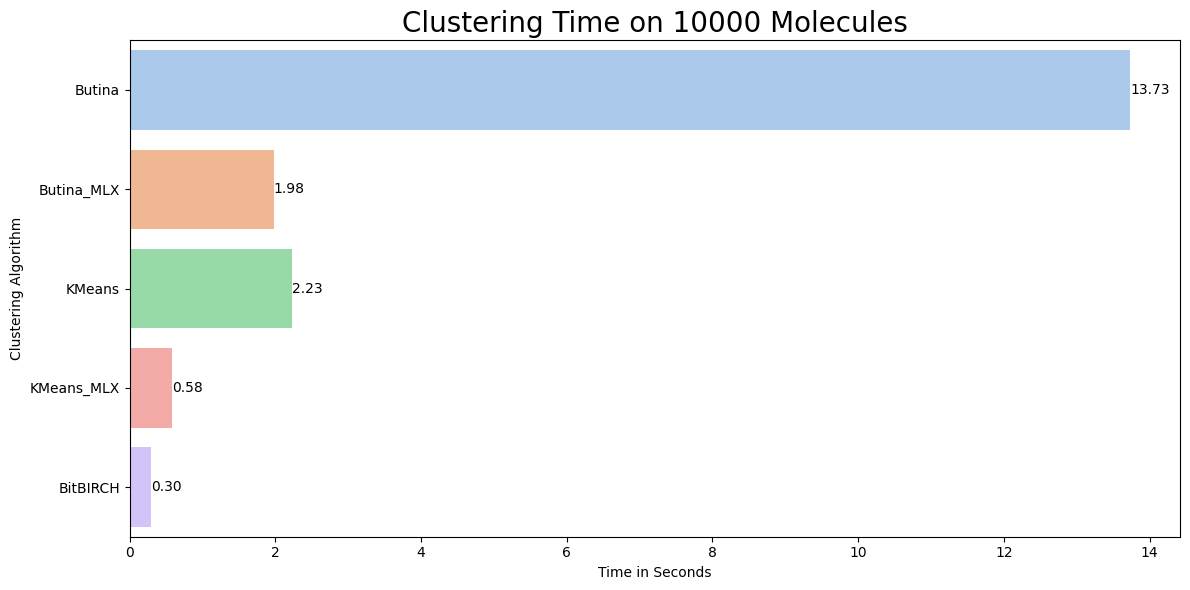

In [17]:
# plot labels
clustering_time = [butina_time, mlx_butina_time, kmeans_time, mlx_kmeans_time, bitbirch_time]
labels = ['Butina', 'Butina_MLX', 'KMeans', 'KMeans_MLX', 'BitBIRCH']
title = f"Clustering Time on {len(mol_list)} Molecules"

# plot
fig, ax = plt.subplots(figsize=(12, 6))
ax = sns.barplot(x=clustering_time, y=labels, palette="pastel", hue=labels, legend=False)
ax.set_title(title, fontsize=20)
for label in ax.containers:
    ax.bar_label(label, fmt="%.2f", fontsize=10)
plt.yticks(fontsize=10)
plt.xticks(fontsize=10)
plt.ylabel("Clustering Algorithm", fontsize=10)
plt.xlabel("Time in Seconds", fontsize=10)
plt.tight_layout()
plt.show()

# Conclusion

The chart looks impressive for calculating Butina and KMeans on MLX.

**However, there is a caveat:**
The time recorded is the clustering. If you take into account generating the fingerprints, then the time will be drastically increased. This is also an issue with converting the fingerprints from an np.array() into an mx.array().